# Embeddings merging strategies analysis

In [ ]:
import pandas as pd
import os
import numpy as np
from typing import Literal

In [2]:
base_path = "../"

#### Load data

In [3]:
df = pd.read_csv(os.path.join(base_path, "gridsearch_merging_strategy.csv"))
df.head()

,DNABERTBACTSTRAT,NT2PHAGESTRAT,NT2BACTSTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,MEGADNABACTSTRAT,F1Score1,Average
0,TruncateStrategy,TruncateStrategy,TruncateStrategy,TfidfStrategy,Tf4idfStrategy,MaxStrategy,0.910256,0.9102
1,TruncateStrategy,TruncateStrategy,TruncateStrategy,MaxStrategy,Tf4idfStrategy,MaxStrategy,0.920198,0.9201
2,TruncateStrategy,TruncateStrategy,TruncateStrategy,MaxStrategy,TruncateStrategy,TruncateStrategy,0.923039,0.9230
3,TruncateStrategy,TruncateStrategy,TruncateStrategy,TruncateStrategy,MaxStrategy,TruncateStrategy,0.925735,0.9257
4,TruncateStrategy,TruncateStrategy,TruncateStrategy,TfidfStrategy,TruncateStrategy,Tf4idfStrategy,0.915788,0.9157


## Analysis

In [57]:
th_high = 0.94
th_low = 0.90
# th_high = 0.95
# th_low = 0.80

array([[<Axes: title={'center': 'Average'}>]], dtype=object)

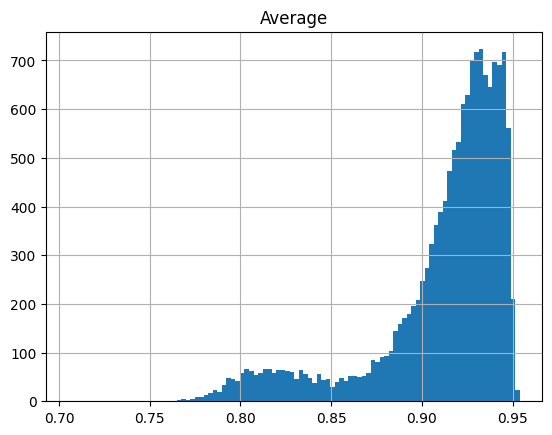

In [ ]:
df.hist(column="Average", bins=100);

In [59]:
df.sort_values(axis=0, by="Average", ascending=False, inplace=True, ignore_index=True)
df.head()

,DNABERTBACTSTRAT,NT2PHAGESTRAT,NT2BACTSTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,MEGADNABACTSTRAT,F1Score1,Average
0,MaxStrategy,TruncateStrategy,Tf4idfStrategy,TfidfStrategy,MaxStrategy,MaxStrategy,0.953854,0.9538
1,MaxStrategy,TruncateStrategy,TfidfStrategy,MaxStrategy,Tf4idfStrategy,MaxStrategy,0.953701,0.9537
2,MaxStrategy,TKPertStrategy,TruncateStrategy,TfidfStrategy,TKPertStrategy,TruncateStrategy,0.953565,0.9535
3,MaxStrategy,TfidfStrategy,TfidfStrategy,TKPertStrategy,TruncateStrategy,TruncateStrategy,0.953387,0.9533
4,MaxStrategy,TfidfStrategy,TruncateStrategy,TfidfStrategy,MaxStrategy,MaxStrategy,0.953267,0.9532


In [60]:
df_best = df[df["Average"] >= th_high]
print(f"Number of elements selected as bests: {len(df_best)}")

df_worse = df[df["Average"] < th_low]
print(f"Number of elements selected as worse: {len(df_worse)}")

Number of elements selected as bests: 2596
Number of elements selected as worse: 3422


In [99]:
DF_COLUMNS = ["NT2PHAGESTRAT", "MEGADNAPHAGESTRAT", "DNABERTPHAGESTRAT", "NT2BACTSTRAT", "MEGADNABACTSTRAT", "DNABERTBACTSTRAT"]
strategies = np.unique(df[DF_COLUMNS].values)

def make_pretty(styler, title: str, cmap: str = "RdYlGn", vmin = None, vmax = None, percentage: bool = False, axis: Literal[0] | None = 0):
    styler.set_caption(title)
    if percentage:
        styler.format(lambda x: f"{x*100:.2f}%" if np.isfinite(x) else x) # type: ignore
    else:
        styler.format(precision=3)
    styler.background_gradient(axis=axis, cmap=cmap, vmin=vmin, vmax=vmax)
    return styler


### Single column analysis

How many of each of them are in the top and bottom

In [62]:
table_best = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
table_worse = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    table_best[column] = df_best[column].value_counts(normalize=True)
    table_worse[column] = df_worse[column].value_counts(normalize=True)

table_best.fillna(0, inplace=True)
table_worse.fillna(0, inplace=True)

In [63]:
table_best.style.pipe(make_pretty, title=f"Best strategies (f1 >= {th_high}: {len(df_best)} exps)", percentage=True)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,19.22%,20.65%,19.22%,35.48%,25.31%,31.74%
TKPertStrategy,20.61%,13.79%,23.92%,8.74%,15.33%,8.32%
Tf4idfStrategy,17.68%,21.88%,18.95%,9.13%,12.48%,16.29%
TfidfStrategy,19.53%,22.46%,18.26%,8.94%,12.21%,14.95%
TruncateStrategy,22.96%,21.22%,19.65%,37.71%,34.67%,28.70%


In [64]:
table_worse.style.pipe(make_pretty, title=f"Worse strategies (f1 < {th_low}: {len(df_worse)} exps)", cmap="RdYlGn_r", percentage=True)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,24.61%,23.03%,21.30%,5.03%,6.17%,8.62%
TKPertStrategy,14.58%,19.43%,18.82%,29.51%,20.16%,18.09%
Tf4idfStrategy,16.89%,17.74%,20.51%,29.72%,34.69%,31.97%
TfidfStrategy,23.00%,18.12%,20.37%,29.60%,35.36%,32.38%
TruncateStrategy,20.92%,21.68%,18.99%,6.14%,3.62%,8.94%


### Single column analysis

How many experiments for each category are in the top/bottom section

In [65]:
table_best_2 = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
table_worse_2 = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    for strat in strategies:
        table_best_2.loc[strat, column] = len(df_best[df_best[column] == strat]) / len(df[df[column] == strat])
        table_worse_2.loc[strat, column] = len(df_worse[df_worse[column] == strat]) / len(df[df[column] == strat])

table_best_2.fillna(0, inplace=True)
table_worse_2.fillna(0, inplace=True)

In [66]:
table_best_2.style.pipe(make_pretty, title=f"Best strategies (f1 >= {th_high}: {len(df_best)} exps)", percentage=True, axis=None)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,15.97%,18.49%,17.23%,31.98%,22.69%,26.37%
TKPertStrategy,21.40%,12.44%,21.50%,7.90%,13.79%,10.95%
Tf4idfStrategy,17.67%,19.63%,17.00%,8.24%,11.19%,13.54%
TfidfStrategy,16.23%,20.12%,16.37%,8.07%,10.95%,12.42%
TruncateStrategy,19.07%,18.97%,17.60%,32.99%,31.05%,23.84%


In [67]:
table_worse_2.style.pipe(make_pretty, title=f"Worse strategies (f1 < {th_low}: {len(df_worse)} exps)", cmap="RdYlGn_r", percentage=True, axis=None)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,26.94%,27.18%,25.17%,5.97%,7.29%,9.44%
TKPertStrategy,19.96%,23.11%,22.30%,35.14%,23.91%,31.39%
Tf4idfStrategy,22.25%,20.98%,24.26%,35.37%,40.99%,35.01%
TfidfStrategy,25.19%,21.40%,24.07%,35.23%,41.78%,35.46%
TruncateStrategy,22.91%,25.54%,22.43%,7.08%,4.28%,9.79%


### Single column analysis: Average score for each strategy

In [70]:
weights_table = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    for strat in strategies:
        weights_table.loc[strat, column] = df[df[column] == strat]["Average"].mean()

weights_table.style.pipe(make_pretty, title="Average score", cmap="RdYlGn", vmin=0.86, vmax=0.95)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,0.908,0.910,0.910,0.930,0.925,0.925
TKPertStrategy,0.913,0.909,0.912,0.901,0.916,0.911
Tf4idfStrategy,0.911,0.913,0.911,0.898,0.892,0.897
TfidfStrategy,0.910,0.914,0.911,0.898,0.892,0.897
TruncateStrategy,0.913,0.910,0.912,0.929,0.930,0.925


In [76]:
weights_table = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
df_top_bottom = df[(df["Average"] >= th_high) | (df["Average"] < th_low)]

for column in DF_COLUMNS:
    for strat in strategies:
        weights_table.loc[strat, column] = df_top_bottom[df_top_bottom[column] == strat]["Average"].mean()

weights_table.style.pipe(make_pretty, title="Average score (only top + bottom)", cmap="RdYlGn", vmin=0.86, vmax=0.95)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,0.890,0.893,0.892,0.935,0.931,0.929
TKPertStrategy,0.897,0.884,0.895,0.874,0.906,0.897
Tf4idfStrategy,0.893,0.899,0.894,0.867,0.864,0.869
TfidfStrategy,0.893,0.900,0.893,0.867,0.865,0.868
TruncateStrategy,0.897,0.893,0.896,0.933,0.937,0.927


## First round removal

In [130]:
remaining_strats = {
    "NT2PHAGESTRAT": ["TruncateStrategy", "MaxStrategy", "TfidfStrategy", "Tf4idfStrategy", "TKPertStrategy"],
    "MEGADNAPHAGESTRAT": ["TruncateStrategy", "MaxStrategy", "TfidfStrategy", "Tf4idfStrategy", "TKPertStrategy"],
    "DNABERTPHAGESTRAT": ["TruncateStrategy", "MaxStrategy", "TfidfStrategy", "Tf4idfStrategy", "TKPertStrategy"],
    "NT2BACTSTRAT": ["TruncateStrategy", "MaxStrategy"],
    "MEGADNABACTSTRAT": ["TruncateStrategy", "MaxStrategy"],
    "DNABERTBACTSTRAT": ["TruncateStrategy", "MaxStrategy"],
}

In [131]:
ndf = df.copy()

for column, strats in remaining_strats.items():
    ndf.drop(ndf[ndf[column].map(lambda x: x not in strats)].index, inplace=True)

print(f"Total elements: {len(ndf)}")
ndf.head()

Total elements: 1000


,DNABERTBACTSTRAT,NT2PHAGESTRAT,NT2BACTSTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,MEGADNABACTSTRAT,F1Score1,Average
2,MaxStrategy,TKPertStrategy,TruncateStrategy,TfidfStrategy,TKPertStrategy,TruncateStrategy,0.953565,0.9535
4,MaxStrategy,TfidfStrategy,TruncateStrategy,TfidfStrategy,MaxStrategy,MaxStrategy,0.953267,0.9532
6,MaxStrategy,TKPertStrategy,TruncateStrategy,Tf4idfStrategy,Tf4idfStrategy,MaxStrategy,0.953001,0.9530
11,MaxStrategy,TKPertStrategy,TruncateStrategy,MaxStrategy,MaxStrategy,MaxStrategy,0.952369,0.9523
14,MaxStrategy,TruncateStrategy,TruncateStrategy,TfidfStrategy,TruncateStrategy,MaxStrategy,0.952001,0.9520


Number of elements selected as bests: 126
Number of elements selected as worse: 104


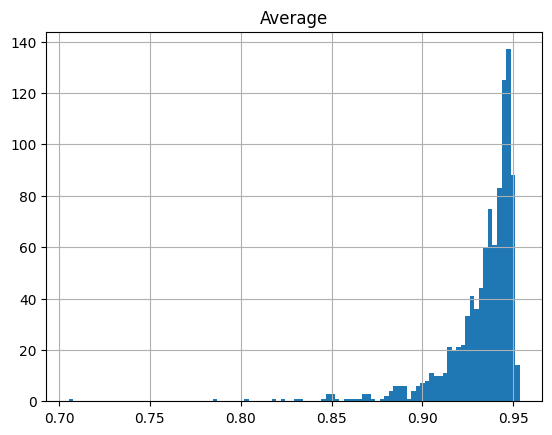

In [132]:
nth_high = 0.948
nth_low = 0.91

ndf_best = ndf[ndf["Average"] >= nth_high]
print(f"Number of elements selected as bests: {len(ndf_best)}")

ndf_worse = ndf[ndf["Average"] < nth_low]
print(f"Number of elements selected as worse: {len(ndf_worse)}")

ndf.hist(column="Average", bins=100);

### Single column analysis

How many of each of them are in the top and bottom

In [133]:
ntable_best = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
ntable_worse = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    ntable_best[column] = ndf_best[column].value_counts(normalize=True)
    ntable_worse[column] = ndf_worse[column].value_counts(normalize=True)

In [134]:
ntable_best.style.pipe(make_pretty, title=f"Best strategies (f1 >= {nth_high}: {len(ndf_best)} exps)", percentage=True)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,17.46%,26.19%,17.46%,34.13%,49.21%,76.19%
TKPertStrategy,28.57%,11.90%,17.46%,nan,nan,nan
Tf4idfStrategy,11.90%,26.19%,21.43%,nan,nan,nan
TfidfStrategy,22.22%,22.22%,21.43%,nan,nan,nan
TruncateStrategy,19.84%,13.49%,22.22%,65.87%,50.79%,23.81%


In [135]:
ntable_worse.style.pipe(make_pretty, title=f"Worse strategies (f1 < {nth_low}: {len(ndf_worse)} exps)", cmap="RdYlGn_r", percentage=True)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,22.12%,17.31%,23.08%,52.88%,62.50%,56.73%
TKPertStrategy,13.46%,23.08%,4.81%,nan,nan,nan
Tf4idfStrategy,24.04%,14.42%,20.19%,nan,nan,nan
TfidfStrategy,24.04%,13.46%,29.81%,nan,nan,nan
TruncateStrategy,16.35%,31.73%,22.12%,47.12%,37.50%,43.27%


### Single column analysis

How many experiments for each category are in the top/bottom section

In [136]:
ntable_best_2 = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
ntable_worse_2 = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    for strat in strategies:
        ntable_best_2.loc[strat, column] = len(ndf_best[ndf_best[column] == strat]) / len(ndf[ndf[column] == strat]) if len(ndf[ndf[column] == strat]) != 0 else np.nan
        ntable_worse_2.loc[strat, column] = len(ndf_worse[ndf_worse[column] == strat]) / len(ndf[ndf[column] == strat]) if len(ndf[ndf[column] == strat]) != 0 else np.nan

In [137]:
ntable_best_2.style.pipe(make_pretty, title=f"Best strategies (f1 >= {nth_high}: {len(ndf_best)} exps)", percentage=True, axis=None)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,11.00%,16.50%,11.00%,8.60%,12.40%,19.20%
TKPertStrategy,18.00%,7.50%,11.00%,nan,nan,nan
Tf4idfStrategy,7.50%,16.50%,13.50%,nan,nan,nan
TfidfStrategy,14.00%,14.00%,13.50%,nan,nan,nan
TruncateStrategy,12.50%,8.50%,14.00%,16.60%,12.80%,6.00%


In [138]:
ntable_worse_2.style.pipe(make_pretty, title=f"Worse strategies (f1 < {nth_low}: {len(ndf_worse)} exps)", cmap="RdYlGn_r", percentage=True, axis=None)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,11.50%,9.00%,12.00%,11.00%,13.00%,11.80%
TKPertStrategy,7.00%,12.00%,2.50%,nan,nan,nan
Tf4idfStrategy,12.50%,7.50%,10.50%,nan,nan,nan
TfidfStrategy,12.50%,7.00%,15.50%,nan,nan,nan
TruncateStrategy,8.50%,16.50%,11.50%,9.80%,7.80%,9.00%
